In this work we will train different neural network models for extracting text and categorical features to predict salaries of vacancies. Dataset: https://www.kaggle.com/c/job-salary-prediction/data.

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [18]:
data = pd.read_csv("../data/Train_rev1.csv", index_col=None)
data.shape

(244768, 12)

In [19]:
data.head()

,Id,Title,FullDescription,LocationRaw,LocationNormalized,ContractType,ContractTime,Company,Category,SalaryRaw,SalaryNormalized,SourceName
0,12612628,Engineering Systems Analyst,Engineering Systems Analyst Dorking Surrey Sal...,"Dorking, Surrey, Surrey",Dorking,NaN,permanent,Gregory Martin International,Engineering Jobs,20000 - 30000/annum 20-30K,25000,cv-library.co.uk
1,12612830,Stress Engineer Glasgow,Stress Engineer Glasgow Salary **** to **** We...,"Glasgow, Scotland, Scotland",Glasgow,NaN,permanent,Gregory Martin International,Engineering Jobs,25000 - 35000/annum 25-35K,30000,cv-library.co.uk
2,12612844,Modelling and simulation analyst,Mathematical Modeller / Simulation Analyst / O...,"Hampshire, South East, South East",Hampshire,NaN,permanent,Gregory Martin International,Engineering Jobs,20000 - 40000/annum 20-40K,30000,cv-library.co.uk
3,12613049,Engineering Systems Analyst / Mathematical Mod...,Engineering Systems Analyst / Mathematical Mod...,"Surrey, South East, South East",Surrey,NaN,permanent,Gregory Martin International,Engineering Jobs,25000 - 30000/annum 25K-30K negotiable,27500,cv-library.co.uk
4,12613647,"Pioneer, Miser Engineering Systems Analyst","Pioneer, Miser Engineering Systems Analyst Do...","Surrey, South East, South East",Surrey,NaN,permanent,Gregory Martin International,Engineering Jobs,20000 - 30000/annum 20-30K,25000,cv-library.co.uk


The distribution is fat-tailed on the right side, which is inconvenient for MSE minimization, therefore we will use log-target.

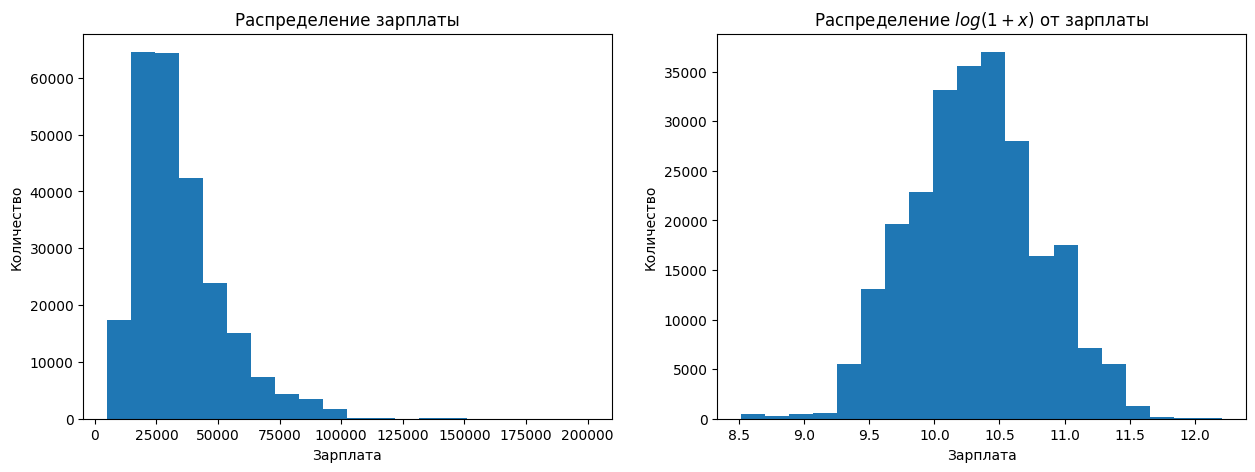

In [39]:
data['Log1pSalary'] = np.log1p(data['SalaryNormalized']).astype('float32')

plt.figure(figsize=[15, 5])
plt.subplot(1, 2, 1)
plt.title('Распределение зарплаты')
plt.xlabel('Зарплата')
plt.ylabel('Количество')
plt.hist(data["SalaryNormalized"], bins=20)

plt.subplot(1, 2, 2)
plt.title('Распределение $log(1 + x)$ от зарплаты')
plt.xlabel('Зарплата')
plt.ylabel('Количество')
plt.hist(data['Log1pSalary'], bins=20)
plt.savefig('/home/antokir/Materials/HW/DiplomaProjectNewFormat/images/distr_for presentation.png')

In [5]:
text_columns = ["Title", "FullDescription"]
categorical_columns = ["Category", "Company", "LocationNormalized", "ContractType", "ContractTime"]
TARGET_COLUMN = "Log1pSalary"

data[categorical_columns] = data[categorical_columns].fillna('NaN') # cast missing values to string "NaN"

data.sample(3)

,Id,Title,FullDescription,LocationRaw,LocationNormalized,ContractType,ContractTime,Company,Category,SalaryRaw,SalaryNormalized,SourceName,Log1pSalary
27151,67896002,Sales Manager,We are currently recruiting for a wellestablis...,"manchester, North West",Manchester,NaN,permanent,Dexter Nicholas Ltd,Sales Jobs,40000 - 50000/annum + commission + package,45000,cv-library.co.uk,10.714440
226462,72441889,Part Time Work from Home,Five selfemployed new colleagues wanted to hel...,Chester Cheshire North West,Chester,part_time,NaN,Hiredonline,Sales Jobs,1000 - 30000 per annum + exellent benefits,15500,totaljobs.com,9.648660
159372,71170804,Sales Manager,"Sales Manager **** **** comm Our client, an ...",UK,UK,NaN,NaN,Moriati Media UK Ltd,Sales Jobs,"40,000 - 45,000 + comm",42500,salestarget.co.uk,10.657283


## Preprocessing text data

In [6]:
print("Raw text:")
print(data["FullDescription"][0])

Raw text:
Engineering Systems Analyst Dorking Surrey Salary ****K Our client is located in Dorking, Surrey and are looking for Engineering Systems Analyst our client provides specialist software development Keywords Mathematical Modelling, Risk Analysis, System Modelling, Optimisation, MISER, PIONEEER Engineering Systems Analyst Dorking Surrey Salary ****K


In [7]:
import nltk

tokenizer = nltk.tokenize.WordPunctTokenizer()
data["FullDescription"] = data["FullDescription"].apply(lambda x: ' '.join(tokenizer.tokenize(x.lower())))
data["Title"] = data["Title"].apply(lambda x: ' '.join(tokenizer.tokenize(str(x).lower())))

In [8]:
print("Tokenized:")
print(data["FullDescription"][0])

Tokenized:
engineering systems analyst dorking surrey salary **** k our client is located in dorking , surrey and are looking for engineering systems analyst our client provides specialist software development keywords mathematical modelling , risk analysis , system modelling , optimisation , miser , pioneeer engineering systems analyst dorking surrey salary **** k


In [9]:
from collections import Counter
token_counts = Counter()

for row in [*data["FullDescription"].values, *data["Title"]]:
    token_counts.update(row.split())

In [10]:
print("Total unique tokens :", len(token_counts))
print('\n'.join(map(str, token_counts.most_common(n=5))))
print('...')
print('\n'.join(map(str, token_counts.most_common()[-3:])))

Total unique tokens : 202704
('and', 2657388)
('.', 2523216)
(',', 2318606)
('the', 2080994)
('to', 2019884)
...
('improvemen', 1)
('techniciancivil', 1)
('mlnlycke', 1)


Text(0.5, 0, 'Word counts')

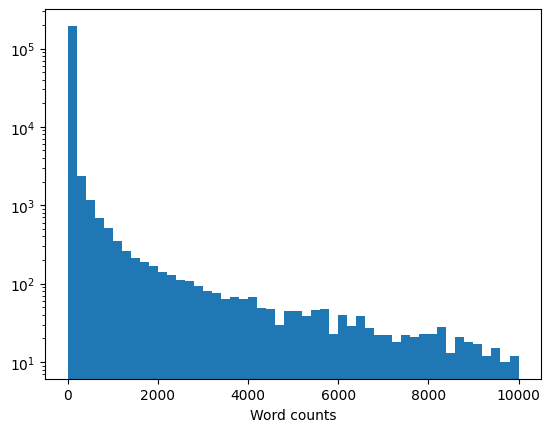

In [11]:
plt.hist(list(token_counts.values()), range=[0, 10**4], bins=50, log=True)
plt.xlabel("Word counts")

In [12]:
min_count = 10

# tokens from token_counts keys that had at least min_count occurrences throughout the dataset
tokens = sorted(t for t, c in token_counts.items() if c >= min_count)

# Special tokens for unknown and empty words
UNK, PAD = "<UNK>", "<PAD>"
tokens = [UNK, PAD] + tokens

In [13]:
print("Vocabulary size:", len(tokens))

Vocabulary size: 34158


In [14]:
token_to_id = {token: id_ for id_, token in enumerate(tokens)}

In [15]:
for category_column in categorical_columns:
    print(f'Number of categories in column "{category_column}": {len(set([category for category in data[category_column]]))}')

Number of categories in column "Category": 29
Number of categories in column "Company": 20813
Number of categories in column "LocationNormalized": 2732
Number of categories in column "ContractType": 3
Number of categories in column "ContractTime": 3


In [16]:
from sklearn.feature_extraction import DictVectorizer

# we only consider top-1k most frequent companies to minimize memory usage
top_companies, top_counts = zip(*Counter(data['Company']).most_common(1000))
recognized_companies = set(top_companies)
data["Company"] = data["Company"].apply(lambda comp: comp if comp in recognized_companies else "Other")

categorical_vectorizer = DictVectorizer(dtype=np.float32, sparse=False)
categorical_vectorizer.fit(data[categorical_columns].apply(dict, axis=1))

DictVectorizer(dtype=<class 'numpy.float32'>, sparse=False)

In [41]:
len(categorical_vectorizer.vocabulary_)

3768

## Creating dataset and dataloader

In [42]:
import torch
from torch.utils.data import Dataset, DataLoader, Sampler
from torch import nn

UNK_ID, PAD_ID = map(token_to_id.get, [UNK, PAD])

class JobsDataset(Dataset):
    def __init__(self, df):
        super().__init__()
        self.data = df
        self.data.index = np.arange(len(self.data))
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, index):
        return self.data.iloc[index]

We will use custom batch sampler for getting batch in collate_fn using `df.iloc[indices]` instead of `[df.iloc[i] for i in indices]`, in our case it will speed up data loading: https://github.com/pytorch/pytorch/issues/4959#issuecomment-362424598

In [43]:
class CustomBatchSampler(Sampler):
    def __init__(self, data_len, batch_size, shuffle=True):
        self.data_len = data_len
        self.batch_size = batch_size
        self.shuffle = shuffle

    def __len__(self):
        return (self.data_len + self.batch_size - 1) // self.batch_size

    def __iter__(self):
        if self.shuffle:
            splits = np.array_split(np.random.permutation(self.data_len), len(self))
        else:
            splits = np.array_split(np.arange(self.data_len), len(self))
        splits = [[split.tolist()] for split in splits]
        return iter(splits)

In [44]:
MAX_SEQ_LEN = float('inf')

def get_tokens_batch(sequences):
    sequences = list(map(str.split, sequences))

    max_len = max(map(len, sequences))
    max_len = min(max_len, MAX_SEQ_LEN)
    
    tokens_batch = torch.full((len(sequences), max_len), PAD_ID)
    for i, seq in enumerate(sequences):
        row_ids = torch.tensor([token_to_id.get(word, UNK_ID) for word in seq[:max_len]], dtype=torch.int)
        tokens_batch[i, :len(row_ids)] = row_ids

    return tokens_batch


def apply_word_dropout(matrix, dropout_prob):
    dropout_mask = torch.distributions.Bernoulli(probs=(1 - dropout_prob)).sample(matrix.size())
    dropout_mask &= matrix != PAD_ID
    matrix[dropout_mask] = UNK_ID
    return matrix


def collate_fn(batch, word_dropout=0):
    batch = batch[0]
    new_batch = {}
    new_batch["Title"] = get_tokens_batch(batch["Title"].values)
    new_batch["FullDescription"] = get_tokens_batch(batch["FullDescription"].values)
    new_batch['Categorical'] = torch.from_numpy(categorical_vectorizer.transform(batch[categorical_columns].apply(dict, axis=1)))
    
    if word_dropout != 0:
        new_batch["FullDescription"] = apply_word_dropout(batch["FullDescription"], word_dropout)
    
    if TARGET_COLUMN in data.columns:
        new_batch[TARGET_COLUMN] = torch.from_numpy(batch[TARGET_COLUMN].values)
    
    return new_batch

In [45]:
from sklearn.model_selection import train_test_split

BATCH_SIZE = 32

train_df, val_df = train_test_split(data, test_size=0.2, random_state=42)

train_data = JobsDataset(train_df)
val_data = JobsDataset(val_df)

train_batch_sampler = CustomBatchSampler(data_len=len(train_data), batch_size=BATCH_SIZE, shuffle=True)
val_batch_sampler = CustomBatchSampler(data_len=len(val_data), batch_size=BATCH_SIZE, shuffle=False)

train_loader = DataLoader(train_data, batch_sampler=train_batch_sampler, collate_fn=collate_fn, num_workers=28)
val_loader = DataLoader(val_data, batch_sampler=val_batch_sampler, collate_fn=collate_fn, num_workers=28)

print("Train size = ", len(train_data))
print("Validation size = ", len(val_data))

Train size =  195814
Validation size =  48954


/home/antokir/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 28 worker processes in total. Our suggested max number of worker in current system is 12, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


## Defining model (LSTM + 1d convolution + GloVe embeddings)

We will use GloVe pretrained token embeddings with 300 features.

In [20]:
#pragma dataset init my_dataset --size 20Gb

!wget -O /home/jupyter/mnt/datasets/my_dataset/glove.zip https://huggingface.co/stanfordnlp/glove/resolve/main/glove.840B.300d.zip

--2024-05-10 10:14:20--  https://huggingface.co/stanfordnlp/glove/resolve/main/glove.840B.300d.zip
Resolving huggingface.co (huggingface.co)... 52.85.5.5, 52.85.5.15, 52.85.5.101, ...
Connecting to huggingface.co (huggingface.co)|52.85.5.5|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://cdn-lfs.huggingface.co/stanfordnlp/glove/f47355dd5b267bd10f08671e513790690233c76a9ffd73aa915d78f894a8912e?response-content-disposition=attachment%3B+filename*%3DUTF-8%27%27glove.840B.300d.zip%3B+filename%3D%22glove.840B.300d.zip%22%3B&response-content-type=application%2Fzip&Expires=1715595261&Policy=eyJTdGF0ZW1lbnQiOlt7IkNvbmRpdGlvbiI6eyJEYXRlTGVzc1RoYW4iOnsiQVdTOkVwb2NoVGltZSI6MTcxNTU5NTI2MX19LCJSZXNvdXJjZSI6Imh0dHBzOi8vY2RuLWxmcy5odWdnaW5nZmFjZS5jby9zdGFuZm9yZG5scC9nbG92ZS9mNDczNTVkZDViMjY3YmQxMGYwODY3MWU1MTM3OTA2OTAyMzNjNzZhOWZmZDczYWE5MTVkNzhmODk0YTg5MTJlP3Jlc3BvbnNlLWNvbnRlbnQtZGlzcG9zaXRpb249KiZyZXNwb25zZS1jb250ZW50LXR5cGU9KiJ9XX0_&Signature=Y2V2N5KZ8zupSTSeb

In [21]:
!unzip /home/jupyter/mnt/datasets/my_dataset/glove.zip

Archive:  /home/jupyter/mnt/datasets/my_dataset/glove.zip
  inflating: glove.840B.300d.txt     


In [22]:
!ls -sh /home/jupyter/mnt/datasets/my_dataset/glove.*

2.1G /home/jupyter/mnt/datasets/my_dataset/glove.zip


In [23]:
from tqdm.auto import tqdm

def load_glove_weights(file_path, vocab, pad_token="<PAD>"):
    print("Loading Glove Weights")
    glove_weights = np.random.normal(0, 1, (len(vocab), 300))
    mask_found = np.zeros(len(vocab), dtype=bool)
    
    with open(file_path, 'r') as f:
        for line in tqdm(f, total=2196018):
            line = line.split()
            token = ' '.join(line[:-300])
            embed = line[-300:]

            if token in vocab:
                ind = vocab[token]
                mask_found[ind] = True
                glove_weights[ind, :] = np.array(list(map(float, embed)), dtype=np.float64)

    print(f"{mask_found.sum()} words from vocab of size {len(vocab)} loaded!")

    glove_weights[vocab[pad_token]] = np.zeros(300, dtype=np.float64)
    return glove_weights, mask_found


glove_path = "glove.840B.300d.txt"
glove_weights, mask_found = load_glove_weights(glove_path, token_to_id, "<PAD>")

Loading Glove Weights


100%|██████████| 2196018/2196018 [05:31<00:00, 6634.07it/s] 

27512 words from vocab of size 34158 loaded!


We will use model with convolutional title encoder, LSTM description encoder and full-connected layer for categorical features. Model concatenates outputs of these encoders into one features vector and uses this vector as input in final full-connected output layer.

In [51]:
class ConvLSTMSalaryPredictor(nn.Module):
    def __init__(self, token_weights=np.zeros((len(token_to_id), 300)), n_cat_features=len(categorical_vectorizer.vocabulary_), hid_size=100):
        super().__init__()
        n_tokens = token_weights.shape[0]
        n_token_features = token_weights.shape[1]
        self.emb = nn.Embedding(num_embeddings=n_tokens, embedding_dim=n_token_features)
        self.emb.weight = nn.Parameter(
                torch.from_numpy(token_weights).to(torch.float),
                requires_grad = True,
            )
        self.conv_title = nn.Sequential(
            nn.ConstantPad1d((3, 0), 0),
            nn.Conv1d(n_token_features, hid_size, 3),
            nn.BatchNorm1d(hid_size),
            nn.ReLU()
        )
        self.lstm_descr = nn.LSTM(
            input_size=n_token_features,
            hidden_size=hid_size,
            num_layers=3,
            bidirectional=True,
            batch_first=True,
        )
        self.cat_linear = nn.Sequential(
            nn.Linear(n_cat_features, hid_size),
            nn.ReLU()
        )
        self.fc = nn.Sequential(
            nn.Linear(4 * hid_size, hid_size),
            nn.BatchNorm1d(hid_size),
            nn.ReLU(),
            nn.Linear(hid_size, 1),
        )
        
    def forward(self, batch):
        device = self.emb.weight.device
    
        title = batch['Title'].to(device)
        full_description = batch['FullDescription'].to(device)
        categorical = batch['Categorical'].to(device)
        
        title_emb = self.emb(title).transpose(1, 2)
        title_conv = self.conv_title(title_emb)
        title_features, _ = torch.max(title_conv, axis=2)

        descr_emb = self.emb(full_description)
        lstm_descr_output, (hn, cn) = self.lstm_descr(descr_emb)
        descr_features = lstm_descr_output.mean(1)

        cat_features = self.cat_linear(categorical)
        all_features = torch.concatenate([title_features, descr_features, cat_features], axis=1)
        result = self.fc(all_features).squeeze(1)
        return result

In [52]:
def get_parameters_number(model):
    print(f'Number of trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}')
    print(f'Number of all parameters: {sum(p.numel() for p in model.parameters())}')

In [53]:
get_parameters_number(ConvLSTMSalaryPredictor())

Number of trainable parameters: 11559801
Number of all parameters: 11559801


## Model training

In [54]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [39]:
import torch.nn.functional as F
from tqdm.auto import tqdm
from IPython.display import clear_output


def train(model, optimizer, train_loader, criterion, device=device):
    model.train()
    losses = []
    for batch in tqdm(train_loader):
        pred = model(batch)

        loss = criterion(pred, batch[TARGET_COLUMN].to(device))
        losses.append(loss.item())
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    return np.mean(losses)

def val(model, val_loader, device=device):
    model.eval()
    
    mse_losses = []
    mae_losses = []

    with torch.no_grad():
        for batch in tqdm(val_loader):
            pred = model(batch)
            target = batch[TARGET_COLUMN].to(device)
            
            mse_loss = F.mse_loss(pred, target)
            mae_loss = F.l1_loss(pred, target)
            
            mse_losses.append(mse_loss.item())
            mae_losses.append(mae_loss.item())
    
    return np.mean(mse_losses), np.mean(mae_losses)

def train_loop(model, optimizer, criterion, train_loader, val_loader, num_epochs):
    train_losses, val_mse_losses, val_mae_losses = [], [], []
    
    for epoch in range(1, num_epochs + 1):
        print(f"epoch: {epoch}")
        train_loss = train(model, optimizer, train_loader, criterion, device=device)
        train_losses.append(train_loss)

        val_mse_loss, val_mae_loss = val(model, val_loader, device=device)
        val_mse_losses.append(val_mse_loss)
        val_mae_losses.append(val_mae_loss)

        clear_output(True)
        fig, ax = plt.subplots(1, 2, figsize=(20, 10))
        fig.suptitle(f'#{epoch}/{num_epochs}:')

        plt.subplot(1, 2, 1)
        plt.title('Train MSE loss')
        plt.plot(train_losses)
        plt.legend()
        plt.grid()

        plt.subplot(1, 2, 2)
        plt.title('Validation losses')
        plt.plot(val_mse_losses, 'r.-', label='MSE')    
        plt.plot(val_mae_losses, 'g.-', label='MAE')
        plt.legend()
        plt.grid()

        plt.show()

        print(f'train MSE losses: {train_losses}' if len(train_losses) < 5 else f'Last 5 train MSE losses: {train_losses[-5:]}')
        print(f'validation MSE losses: {val_mse_losses}' if len(val_mse_losses) < 5 else f'Last 5 validation MSE losses: {val_mse_losses[-5:]}')
        print(f'validation MAE losses: {val_mae_losses}' if len(val_mae_losses) < 5 else f'Last 5 validation MAE losses: {val_mae_losses[-5:]}')

    torch.save(model.state_dict(), f'{type(model).__name__}.weights')

    return train_losses, val_mse_losses, val_mae_losses

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


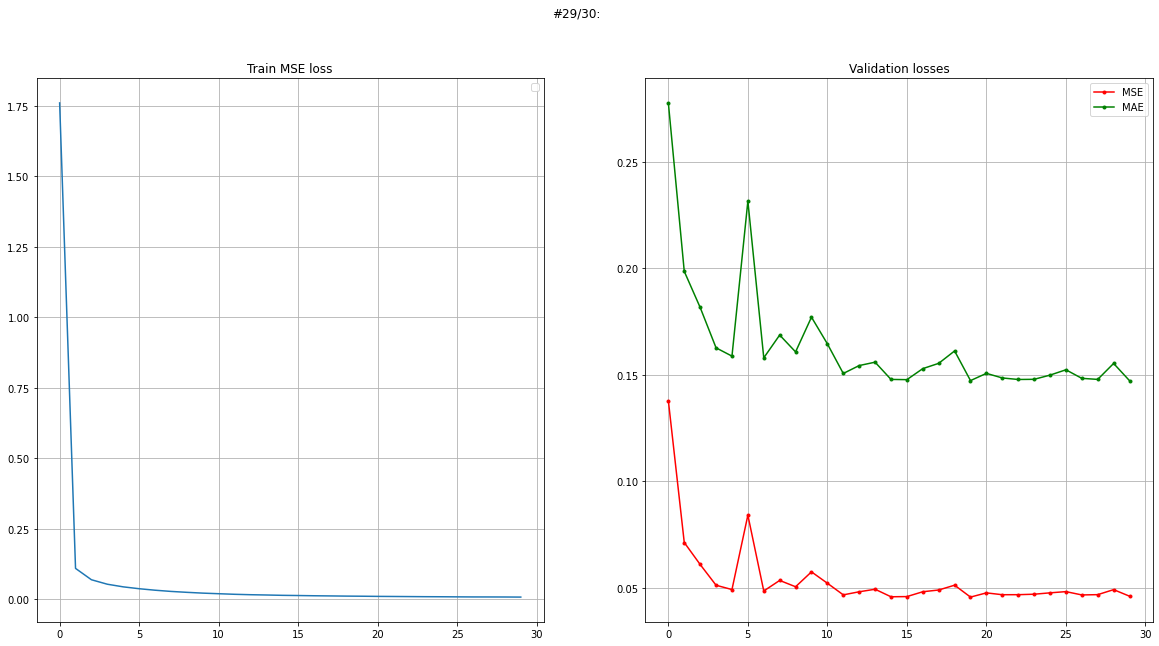

Last 5 train MSE losses: [0.008932911268084652, 0.00864234073376709, 0.008583578911915824, 0.008430789306522439, 0.00810986281137874]
Last 5 validation MSE losses: [0.04808613631959542, 0.04652807043828801, 0.04666210761342465, 0.04901794561860608, 0.04594141449414048]
Last 5 validation MAE losses: [0.15232746601104735, 0.1483111746950087, 0.1478123084733299, 0.1553085564885264, 0.14721245201779345]


In [40]:
EPOCHS = 30
criterion = nn.MSELoss()
conv_lstm_model = ConvLSTMSalaryPredictor().to(device)
optimizer = torch.optim.Adam(conv_lstm_model.parameters(), lr=1e-3)

conv_lstm_train_losses, conv_lstm_val_mse_losses, conv_lstm_val_mae_losses = train_loop(conv_lstm_model, optimizer, criterion, train_loader, val_loader, num_epochs=EPOCHS)

## Defining model (BERT)

Now we will train BERT, for this we should build another dataloader, because BERT uses another tokenizer. Also we will merge title and description columns, because for processing text data we only want to use BERT, and it will be expensive to use 2 BERT models for title and description separately.

In [41]:
data['TitleAndDescription'] = data['Title'] + '; ' + data['FullDescription']
data.sample(5)

,Id,Title,FullDescription,LocationRaw,LocationNormalized,ContractType,ContractTime,Company,Category,SalaryRaw,SalaryNormalized,SourceName,Log1pSalary,TitleAndDescription
28053,67946172,business intelligence consultant,introduction business intelligence consultant ...,London,London,NaN,NaN,Matchtech Group plc.,Engineering Jobs,"35,000 - 40,000/yr",37500,rengineeringjobs.com,10.532123,business intelligence consultant; introduction...
164517,71275401,junior sous chef / cdp live in available,graze kitchen and bar in bury st . edmunds are...,Bury St. Edmunds Suffolk East Anglia,UK,NaN,NaN,Other,Hospitality & Catering Jobs,"From 15,000 to 18,000 per annum Salary will be...",16500,caterer.com,9.711176,junior sous chef / cdp live in available; graz...
106904,69593853,graduate trainee recruitment consultant,"as a tech savvy , vibrant and constantly evolv...",City London South East,London,NaN,permanent,Searchability UK Ltd,Sales Jobs,18000.00 per annum + Commission + Benefits,18000,totaljobs.com,9.798182,graduate trainee recruitment consultant; as a ...
233389,72480955,hr advisor / consultant,hr advisor / consultant central manchester ***...,Manchester,Manchester,NaN,permanent,Other,HR & Recruitment Jobs,22-28k,25000,jobsite.co.uk,10.126671,hr advisor / consultant; hr advisor / consulta...
196347,71813683,senior marketing manager,our client is looking for outstanding candidat...,City of London - London,The City,full_time,permanent,UKStaffsearch,"PR, Advertising & Marketing Jobs",70000 - 80000,75000,ukstaffsearch.com,11.225257,senior marketing manager; our client is lookin...


Loading BERT (BERT-Tiny) model and tokenizer:

In [55]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "google/bert_uncased_L-2_H-128_A-2"
bert_tiny_tokenizer = AutoTokenizer.from_pretrained(model_name)
num_labels = 100
bert_tiny_model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels).to(device)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google/bert_uncased_L-2_H-128_A-2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [56]:
get_parameters_number(bert_tiny_model)

Number of trainable parameters: 4398820
Number of all parameters: 4398820


In [74]:
def collate_fn_with_tokenizer(batch, tokenizer=bert_tiny_tokenizer):
    batch = batch[0]
    new_batch = {}
    new_batch['TitleAndDescription'] = tokenizer(batch['TitleAndDescription'].values.tolist(), padding=True, truncation=True, max_length=512, return_tensors="pt")
    new_batch['Categorical'] = torch.from_numpy(categorical_vectorizer.transform(batch[categorical_columns].apply(dict, axis=1)))
    
    if TARGET_COLUMN in data.columns:
        new_batch[TARGET_COLUMN] = torch.from_numpy(batch[TARGET_COLUMN].values)
    
    return new_batch

In [75]:
from sklearn.model_selection import train_test_split

BATCH_SIZE = 32

train_df, val_df = train_test_split(data, test_size=0.2, random_state=42)

train_data = JobsDataset(train_df)
val_data = JobsDataset(val_df)

train_batch_sampler = CustomBatchSampler(data_len=len(train_data), batch_size=BATCH_SIZE, shuffle=True)
val_batch_sampler = CustomBatchSampler(data_len=len(val_data), batch_size=BATCH_SIZE, shuffle=False)

train_loader = DataLoader(train_data, batch_sampler=train_batch_sampler, collate_fn=collate_fn_with_tokenizer, num_workers=28)
val_loader = DataLoader(val_data, batch_sampler=val_batch_sampler, collate_fn=collate_fn_with_tokenizer, num_workers=28)

print("Train size = ", len(train_data))
print("Validation size = ", len(val_data))

Train size =  195814
Validation size =  48954


In [76]:
bert_tiny_model

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 128, padding_idx=0)
      (position_embeddings): Embedding(512, 128)
      (token_type_embeddings): Embedding(2, 128)
      (LayerNorm): LayerNorm((128,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-1): 2 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=128, out_features=128, bias=True)
              (key): Linear(in_features=128, out_features=128, bias=True)
              (value): Linear(in_features=128, out_features=128, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=128, out_features=128, bias=True)
              (LayerNorm): LayerNorm((128,), eps=1e-12, e

In [77]:
class BERTSalaryPredictor(nn.Module):
    def __init__(self,  bert=bert_tiny_model, n_cat_features=len(categorical_vectorizer.vocabulary_), hid_size=num_labels):
        super().__init__()
        self.bert = bert
        self.fc = nn.Sequential(
            nn.Linear(2 * hid_size, hid_size),
            nn.ReLU(),
            nn.Linear(hid_size, 1)
        )
        self.cat_linear = nn.Sequential(
            nn.Linear(n_cat_features, hid_size),
            nn.ReLU()
        )
        
    def forward(self, batch):
        device = self.bert.device
    
        title_and_description = batch['TitleAndDescription'].to(device)
        categorical = batch['Categorical'].to(device)

        title_and_desrc_features = self.bert(**title_and_description).logits
        cat_features = self.cat_linear(categorical)
        
        all_features = torch.concatenate([title_and_desrc_features, cat_features], axis=1)
        result = self.fc(all_features).squeeze(1)
        return result

In [78]:
get_parameters_number(ConvLSTMSalaryPredictor())

Number of trainable parameters: 4795921
Number of all parameters: 4795921


In [79]:
import os

os.environ["TOKENIZERS_PARALLELISM"] = "false"

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


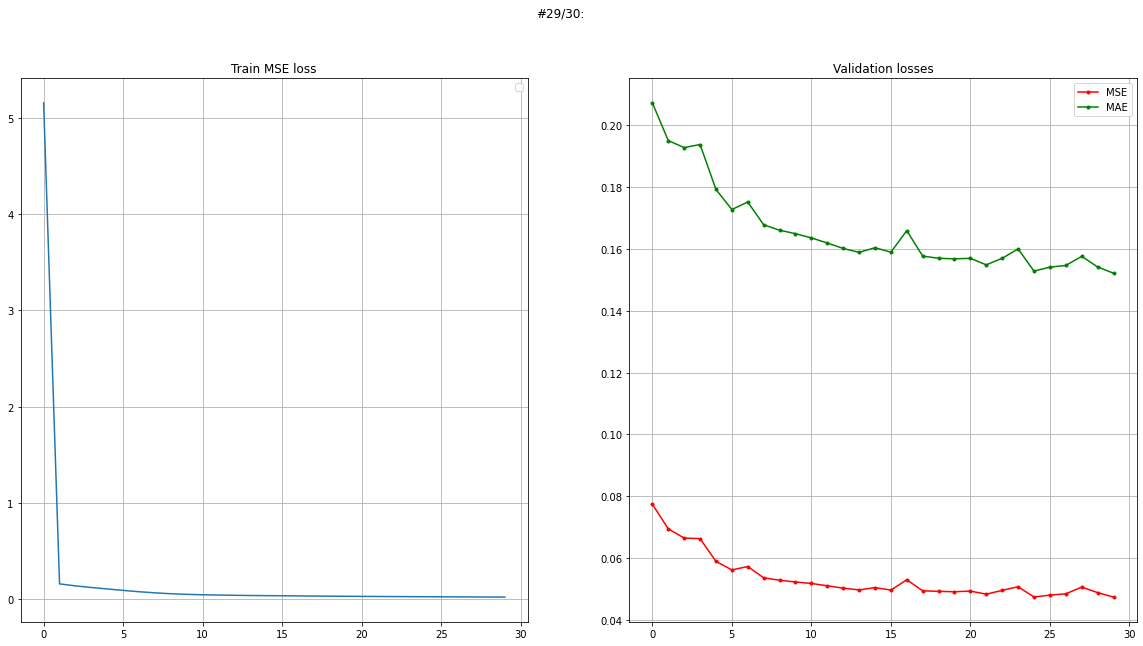

Last 5 train MSE losses: [0.02621335680474789, 0.025417805323681604, 0.024641368431541338, 0.02398859372094663, 0.023253902453119604]
Last 5 validation MSE losses: [0.04813304016171815, 0.04856707040476156, 0.05071697518582535, 0.048944162962093855, 0.047498060179131676]
Last 5 validation MAE losses: [0.15402243933062149, 0.15456430498583645, 0.15750247195752617, 0.1540791185852749, 0.1520539744276237]


In [80]:
EPOCHS = 30
criterion = nn.MSELoss()
bert_tiny_salary_predictor = BERTSalaryPredictor().to(device)
optimizer = torch.optim.Adam(bert_tiny_salary_predictor.parameters(), lr=2e-5)

bert_tiny_train_losses, bert_tiny_val_mse_losses, bert_tiny_val_mae_losses = train_loop(bert_tiny_salary_predictor, optimizer, criterion, train_loader, val_loader, num_epochs=EPOCHS)